# Task 2 - Generative AI: Domain-Specific Fine-Tuning Pipeline

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/GimsaraK/CDAZZDEV-MLE-Gimsara_Elgiriyage/blob/main/task2_genai/task2_finetuning.ipynb)

CDAZZDEV Senior Machine Learning Engineer Technical Assessment - Gimsara Elgiriyage

## 0. Setup

GPU check, dependency installation, and secrets loaded from Colab Secrets. No credentials are hardcoded.

In [1]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'Implement the Task 2A dataset plan', Date: 2026-10-08 (see CITATIONS.md Entry 8)

# Colab clones the public repo and installs Task 2 requirements. Locally we only find the repo root.
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/GimsaraK/CDAZZDEV-MLE-Gimsara_Elgiriyage.git"
REPO_NAME = "CDAZZDEV-MLE-Gimsara_Elgiriyage"
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    repo_root = Path("/content") / REPO_NAME
    if not repo_root.exists():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(repo_root)], check=True)
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-r", str(repo_root / "task2_genai" / "requirements.txt")],
        check=True,
    )
else:
    here = Path.cwd().resolve()
    repo_root = here if (here / "task2_genai").exists() else here.parent
# Both branches import task2_genai from the repo root.
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print("Running in Colab:", IN_COLAB)
print("Repository root :", repo_root)


Running in Colab: False
Repository root : E:\Technical Assessments\CDAZZDEV-SMLE


# Part 2A - Use Case Definition and Dataset Engineering

## 1. Problem Statement

Closed-book compliance assistant for the fictional company Northwind Components. The model does not receive the policy manual in the user turn. It has to apply the rules it was trained on.

| | |
|---|---|
| Input | One employee scenario: who did what, and what they want |
| Output | JSON with `policy_ids`, `required_action`, and `rationale` |
| Correct | Every id is in the manual, or `["NONE"]` when no rule applies, and the action is the one that clause states |
| Incorrect | An unknown id, the wrong clause, an action the clause does not allow, or a rule that was invented |

A generic chatbot answer, or a paragraph that does not name a policy, is incorrect. The manual is fictional and is not legal advice.


In [2]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'Implement the Task 2A dataset plan', Date: 2026-10-08 (see CITATIONS.md Entry 8)

# Show the closed-book contract: the user turn is a scenario, the label is JSON from the manual.
import json
from task2_genai.src.manual import load_manual
from task2_genai.src import config

manual = load_manual()
print("Company:", manual["company"])
print("Input : one employee scenario. The policy manual is not included in the user turn.")
print("Output: JSON with policy_ids, required_action, and rationale.")
print('Correct  : every id is in the manual, or ["NONE"] when nothing applies, and the action matches that clause.')
print("Incorrect: an unknown id, the wrong clause, an action the clause does not allow, or an invented rule.")
print("Policies:")
for policy in manual["policies"]:
    print(f"  {policy['id']}  {policy['topic']}")
print("Teacher:", config.TEACHER_MODEL_GROQ)
print("Student chat template:", config.STUDENT_MODEL)


Company: Northwind Components
Input : one employee scenario. The policy manual is not included in the user turn.
Output: JSON with policy_ids, required_action, and rationale.
Correct  : every id is in the manual, or ["NONE"] when nothing applies, and the action matches that clause.
Incorrect: an unknown id, the wrong clause, an action the clause does not allow, or an invented rule.
Policies:
  NW-LEAVE  leave
  NW-EXPENSE  expenses
  NW-GIFT  gifts
  NW-PRIVACY  privacy
  NW-SAFETY  safety
  NW-REMOTE  remote
  NW-REPORT  reporting
  NW-ACCEPT  acceptable_use
Teacher: openai/gpt-oss-120b
Student chat template: Qwen/Qwen2.5-1.5B-Instruct


## 2. Synthetic Data Generation (Teacher Model)

The teacher is Groq `openai/gpt-oss-120b`. OpenRouter is called only when Groq returns nothing that passes validation. Eight policy topics are crossed with five situation types, and each cell keeps 5 scenarios that survive the schema check and the exact / character 5-gram duplicate checks. If `accepted.jsonl` already has 200 rows, this cell loads them and does not call the teacher.

In [3]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'Implement the Task 2A dataset plan', Date: 2026-10-08 (see CITATIONS.md Entry 8)

# Load the committed JSONL when it is already complete. Call the teacher only to fill a gap.
import json
from task2_genai.src import config
from task2_genai.src.client import load_api_keys
from task2_genai.src.generate import _read_jsonl, generate_dataset

keys = load_api_keys()
print("GROQ_API_KEY set:" , keys["GROQ_API_KEY"])
print("OPENROUTER_API_KEY set:", keys["OPENROUTER_API_KEY"])

accepted = _read_jsonl(config.ACCEPTED_PATH)
if len(accepted) >= config.TARGET_ACCEPTED:
    print(f"Loaded {len(accepted)} accepted rows from {config.ACCEPTED_PATH.name}. Teacher was not called.")
    generate_dataset()
else:
    print("Accepted file is short. Generating the remaining cells.")
    generate_dataset()

report = json.loads(config.GENERATION_REPORT_PATH.read_text(encoding="utf-8"))
print(json.dumps(report, indent=2))


GROQ_API_KEY set: True
OPENROUTER_API_KEY set: True


2026-10-08 21:57:01,015 | INFO | task2.generate | Loaded 200 accepted rows; teacher was not called


Loaded 200 accepted rows from accepted.jsonl. Teacher was not called.
{
  "returned": 200,
  "schema_rejected": 0,
  "exact_dropped": 0,
  "near_dropped": 0,
  "accepted": 200,
  "repair_calls": 2,
  "fallback_calls": 0,
  "provider_failed": 0,
  "train": 160,
  "val": 20,
  "test": 20,
  "teacher_model": "openai/gpt-oss-120b",
  "student_model": "Qwen/Qwen2.5-1.5B-Instruct"
}


## 3. Dataset Diversity Analysis

Prompt length distribution and keyword / topic frequency.

{
  "length_words": {
    "n": 200,
    "min": 40,
    "median": 64.0,
    "p90": 96.0,
    "max": 149,
    "mean": 68.0
  },
  "topic_counts": {
    "acceptable_use": 25,
    "expenses": 25,
    "gifts": 25,
    "leave": 25,
    "privacy": 25,
    "remote": 25,
    "reporting": 25,
    "safety": 25
  },
  "situation_counts": {
    "borderline": 40,
    "clear_breach": 40,
    "compliant": 40,
    "not_covered": 40,
    "two_policy": 40
  },
  "top_keywords": [
    {
      "token": "company",
      "count": 135
    },
    {
      "token": "personal",
      "count": 128
    },
    {
      "token": "laptop",
      "count": 79
    },
    {
      "token": "policy",
      "count": 73
    },
    {
      "token": "manager",
      "count": 70
    },
    {
      "token": "also",
      "count": 60
    },
    {
      "token": "software",
      "count": 56
    },
    {
      "token": "expense",
      "count": 53
    },
    {
      "token": "gift",
      "count": 52
    },
    {
      "token": "day

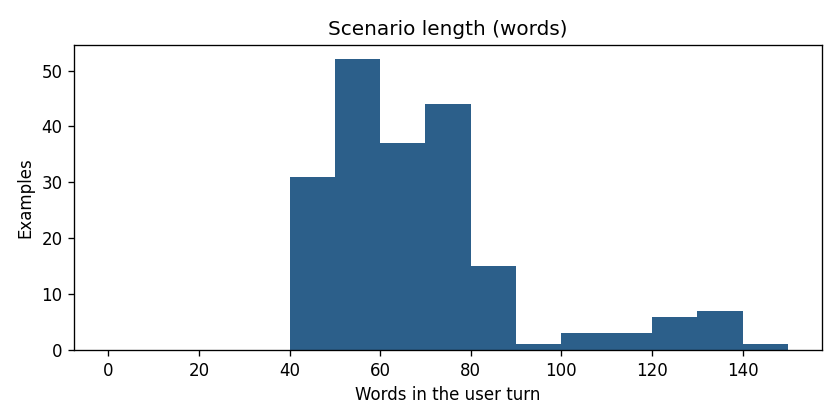

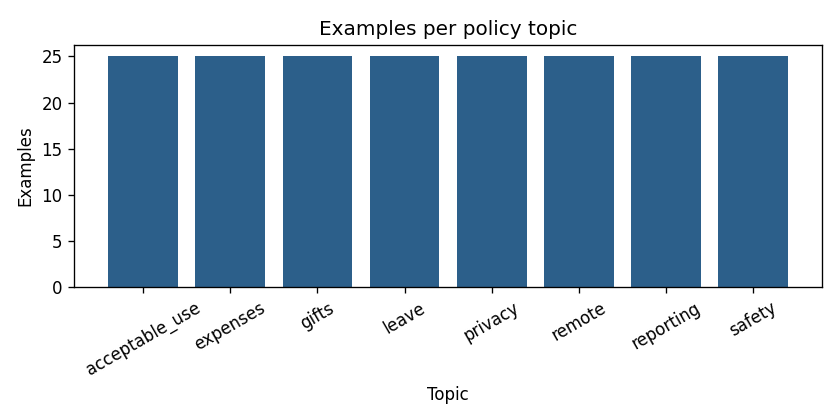

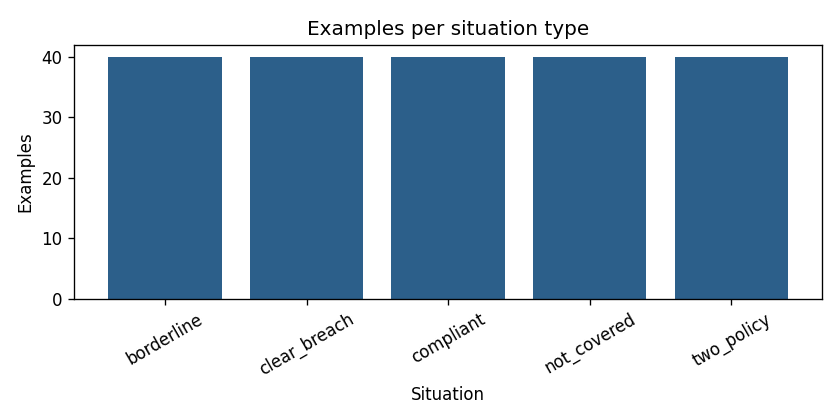

In [4]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'Implement the Task 2A dataset plan', Date: 2026-10-08 (see CITATIONS.md Entry 8)

# Length histogram, topic and situation counts, and the top scenario keywords.
import json
from IPython.display import Image, display
from task2_genai.src import config
from task2_genai.src.diversity import diversity_report
from task2_genai.src.generate import _read_jsonl

rows = _read_jsonl(config.ACCEPTED_PATH)
report = diversity_report(rows)
public = {key: value for key, value in report.items() if key != "lengths"}
print(json.dumps(public, indent=2))
for name in ("prompt_length_hist.png", "topic_frequency.png", "situation_frequency.png"):
    display(Image(filename=str(config.OUTPUTS_DIR / name)))


## 4. Chat-Template Formatting and 80 / 10 / 10 Split

Each JSONL row has `messages` (system, user, assistant) and `text`, the Qwen2.5 ChatML rendering of those turns. The split is 160 train / 20 validation / 20 test, and every topic appears in all three files.

In [5]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'Implement the Task 2A dataset plan', Date: 2026-10-08 (see CITATIONS.md Entry 8)

# Confirm 160/20/20, topic coverage, and that our ChatML string matches the Qwen tokenizer.
import json
from collections import Counter
from task2_genai.src import config
from task2_genai.src.generate import _read_jsonl

def _load(path):
    return _read_jsonl(path)

train, val, test = _load(config.TRAIN_PATH), _load(config.VAL_PATH), _load(config.TEST_PATH)
print(f"train {len(train)} / val {len(val)} / test {len(test)}")
for name, part in ("train", train), ("val", val), ("test", test):
    print(name, dict(sorted(Counter(row["topic"] for row in part).items())))

sample = train[0]
print("Roles:", [message["role"] for message in sample["messages"]])
print("--- rendered template (first 400 chars) ---")
print(sample["text"][:400])

# Confirm the saved string against Qwen2.5's chat template.
# transformers is installed on Colab with the task requirements. If it is absent,
# render the published tokenizer_config.json template with jinja2 instead.
def _render_published(messages):
    import requests
    from jinja2 import Environment
    url = "https://huggingface.co/" + config.STUDENT_MODEL + "/raw/main/tokenizer_config.json"
    template = requests.get(url, timeout=60).json()["chat_template"]
    return Environment().from_string(template).render(
        messages=messages, tools=None, add_generation_prompt=False
    )

try:
    from transformers import AutoTokenizer
    tokenizer = AutoTokenizer.from_pretrained(config.STUDENT_MODEL)
    rendered = tokenizer.apply_chat_template(sample["messages"], tokenize=False, add_generation_prompt=False)
    source = "transformers"
except Exception:
    rendered = _render_published(sample["messages"])
    source = "published tokenizer_config.json"
print("Template source:", source)
print("Template match:", rendered == sample["text"])


train 160 / val 20 / test 20
train {'acceptable_use': 22, 'expenses': 19, 'gifts': 19, 'leave': 19, 'privacy': 18, 'remote': 21, 'reporting': 21, 'safety': 21}
val {'acceptable_use': 1, 'expenses': 5, 'gifts': 2, 'leave': 4, 'privacy': 3, 'remote': 2, 'reporting': 2, 'safety': 1}
test {'acceptable_use': 2, 'expenses': 1, 'gifts': 4, 'leave': 2, 'privacy': 4, 'remote': 2, 'reporting': 2, 'safety': 3}
Roles: ['system', 'user', 'assistant']
--- rendered template (first 400 chars) ---
<|im_start|>system
You are the compliance assistant for Northwind Components. Answer only from Northwind policy you were trained on. Do not invent rules, limits, or deadlines.
Return a JSON object with exactly these keys:
- policy_ids: an array of policy ids, or ["NONE"] when no Northwind policy applies
- required_action: what the employee or the manager must do
- rationale: one or two sentences c


Template source: published tokenizer_config.json
Template match: True


# Part 2B - Fine-Tuning Execution

## 5. Base Model Loading with 4-bit NF4 Quantization

The base model is `Qwen/Qwen2.5-1.5B-Instruct` loaded with `BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4", bnb_4bit_use_double_quant=True, bnb_4bit_compute_dtype=float16)`. LoRA is applied to that quantized model. A T4 has no bfloat16, so the compute dtype is float16.

In [ ]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'Implement the Task 2B QLoRA plan', Date: 2026-10-08 (see CITATIONS.md Entry 10)

# 4-bit NF4 load plus the LoRA adapter. Without CUDA this cell only explains why it stopped.
from task2_genai.src.qlora import load_student
from task2_genai.src.train_config import OOM_STEPS

try:
    import torch
    cuda_ready = torch.cuda.is_available()
except ImportError:
    torch = None
    cuda_ready = False
active_step = 0
adapter_dir = None
if not cuda_ready:
    print("Skipped: QLoRA needs a CUDA GPU. Run this notebook on a Colab T4.")
    print("The load uses BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type='nf4',")
    print("bnb_4bit_use_double_quant=True, bnb_4bit_compute_dtype=float16).")
else:
    # Step 0 is the intended run: length 512 and attention plus MLP.
    model, tokenizer = load_student(OOM_STEPS[0]["target_modules"])
    model.print_trainable_parameters()
    print("GPU:", torch.cuda.get_device_name(0))
    print("Quantization: 4-bit NF4, double quant, compute dtype float16")


## 6. Hyperparameters and Justification

Every value below is set in `src/train_config.py`. A T4 has no bfloat16, so compute stays in float16. The test split is not in this table and is not loaded by the trainer.


In [ ]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'Implement the Task 2B QLoRA plan', Date: 2026-10-08 (see CITATIONS.md Entry 10)

# Print the full parameter table. This cell does not need a GPU.
import pandas as pd
from task2_genai.src.train_config import reason_table

table = pd.DataFrame(reason_table(), columns=["Parameter", "Value", "Reason"])
display(table)


## 7. Training and Loss Monitoring

Three epochs. Train loss and validation loss are printed once per epoch, saved to `outputs/loss_history.json`, and plotted to `outputs/loss_curve.png`. If validation loss does not fall, the cell says so.

In [ ]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'Implement the Task 2B QLoRA plan', Date: 2026-10-08 (see CITATIONS.md Entry 10)

# Train for 3 epochs. On CUDA OOM, retry the next smaller step and record which one ran.
import json
from pathlib import Path
from IPython.display import Image, display
from task2_genai.src import config
from task2_genai.src.qlora import load_student, make_trainer, resolve_max_length, save_loss_plot
from task2_genai.src.train_config import OOM_STEPS, losses_by_epoch, validation_loss_fell

loss_table = None
oom_log = "Training did not run in this session (no CUDA GPU)."
if not cuda_ready:
    print(oom_log)
else:
    import gc
    notes = []
    trainer = None
    # Raise 512 to 768 only when a training row does not fit. Later steps stay short.
    chosen_length, longest_tokens = resolve_max_length(tokenizer, OOM_STEPS[0]["max_seq_length"])
    print("Longest train row: %d tokens. Step 0 cap: %d." % (longest_tokens, chosen_length))
    for step in OOM_STEPS:
        # A later step rebuilds the adapter. The previous model is dropped first.
        if step["step"] != active_step:
            trainer = None
            del model
            gc.collect()
            torch.cuda.empty_cache()
            model, tokenizer = load_student(step["target_modules"])
            active_step = step["step"]
        length = chosen_length if step["step"] == 0 else step["max_seq_length"]
        adapter_dir = Path("/content/qlora-out") if IN_COLAB else config.OUTPUTS_DIR / "adapters"
        try:
            trainer = make_trainer(model, tokenizer, length, adapter_dir)
            trainer.train()
            # load_best_model_at_end has already restored the lowest eval loss.
            trainer.save_model(str(adapter_dir))
            if step["step"] == 0:
                notes.append(
                    "No OOM. Step 0 finished (max length %d, %d target modules)."
                    % (length, len(step["target_modules"]))
                )
            else:
                notes.append(
                    "Step %d finished after the earlier out-of-memory error (max length %d, %d target modules)."
                    % (step["step"], length, len(step["target_modules"]))
                )
            break
        except RuntimeError as exc:
            if "out of memory" not in str(exc).lower():
                raise
            trainer = None
            gc.collect()
            torch.cuda.empty_cache()
            notes.append("Step %d hit CUDA out of memory. %s" % (step["step"], exc))
            print(notes[-1])
    else:
        notes.append("All three OOM steps failed. See the messages above.")
    oom_log = " ".join(notes)
    if trainer is not None and getattr(trainer.state, "log_history", None):
        loss_table = losses_by_epoch(trainer.state.log_history)
        print("Epoch | train loss | val loss")
        for row in loss_table:
            print(row["epoch"], row["train_loss"], row["val_loss"])
        history_path = config.OUTPUTS_DIR / "loss_history.json"
        history_path.write_text(json.dumps(loss_table, indent=2), encoding="utf-8")
        plot_path = config.OUTPUTS_DIR / "loss_curve.png"
        save_loss_plot(loss_table, plot_path)
        display(Image(filename=str(plot_path)))
        if validation_loss_fell(loss_table):
            print("Validation loss fell from the first logged epoch to the last.")
        else:
            print("Validation loss did not fall from the first logged epoch to the last.")
    print(oom_log)


## 8. Merge Adapters and Push to Hugging Face Hub

The adapter is merged with `merge_and_unload()` onto a fresh float16 copy of the base model. The 4-bit training model is not merged. `HF_TOKEN` comes from Colab Secrets and is not printed.

In [ ]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'Implement the Task 2B QLoRA plan', Date: 2026-10-08 (see CITATIONS.md Entry 10)

# Merge the best adapter into a fresh float16 base model and push that model.
# The 4-bit training copy is not the model that gets merged.
import os
from pathlib import Path
from task2_genai.src.client import load_api_keys
from task2_genai.src.qlora import merge_and_push
from task2_genai.src.train_config import ENV_HF_TOKEN, HF_REPO_ID

if not cuda_ready or adapter_dir is None or loss_table is None:
    print("Skipped: merge runs after a finished CUDA training run.")
else:
    # Colab Secrets, or a local .env. The token is not printed.
    if IN_COLAB:
        from google.colab import userdata
        os.environ[ENV_HF_TOKEN] = userdata.get(ENV_HF_TOKEN)
    else:
        load_api_keys()
    token = os.environ.get(ENV_HF_TOKEN, "").strip()
    if not token:
        print("Skipped: HF_TOKEN is not set. Add it in Colab Secrets and rerun this cell.")
    else:
        save_dir = Path("/content/northwind-merged") if IN_COLAB else Path("/tmp/northwind-merged")
        url = merge_and_push(adapter_dir, save_dir, token)
        print("Public model:", url)
        print("Hub repo id:", HF_REPO_ID)


## 9. Out-of-Memory Debugging Log

If the T4 runs out of memory, section 7 retries in this order and records which step finished:

1. Max length 512, LoRA on attention and MLP (the intended run).
2. Max length 384, same modules.
3. Max length 384, attention projections only (`q_proj`, `k_proj`, `v_proj`, `o_proj`).

A run that does not hit an out-of-memory error says so. No failure is invented.


In [ ]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'Implement the Task 2B QLoRA plan', Date: 2026-10-08 (see CITATIONS.md Entry 10)

# The training cell writes oom_log. This cell repeats it next to the planned order.
from task2_genai.src.train_config import OOM_STEPS

print("Planned fallback order:")
for step in OOM_STEPS:
    print(
        "  step %d: max length %d, modules %s"
        % (step["step"], step["max_seq_length"], ", ".join(step["target_modules"]))
    )
print()
print(oom_log if "oom_log" in dir() else "Training cell has not run yet.")


# Part 2C - Evaluation and Baseline Comparison

## 10. ROUGE-L: Base vs Fine-Tuned

Both models answer the same 20 held-out rows from `test.jsonl`, using the system and user turns stored in each row (the same system prompt the training rows use). The base model gets that system prompt and no fine-tuning. Both run in float16 with plain greedy decoding. The fine-tuned model is loaded from the public Hub repo, which also checks the published link, or from the merged folder of section 8 if the push did not happen. Answers are saved to `outputs/eval_predictions.jsonl`, so the metric and review cells can be re-run without a GPU.

ROUGE-L is computed on the whole answer in canonical form (compact JSON with sorted keys, the form the gold answers use), so key order and whitespace do not cost points. It is also computed on the `required_action` and `rationale` fields alone. The domain checks need no model: strict JSON validity, exact `policy_ids`, ids that are not in the manual, and `["NONE"]` on the rows the manual does not cover.


In [ ]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'Implement the Task 2C evaluation plan' (see CITATIONS.md Entry 12)

# Generate base and fine-tuned answers on the test split. Without CUDA, reuse the saved file.
from task2_genai.src import config
from task2_genai.src import eval_config as ec
from task2_genai.src.eval_metrics import build_prediction_records, load_test_rows, read_predictions, write_predictions

try:
    import torch
    eval_cuda = torch.cuda.is_available()
except ImportError:
    eval_cuda = False

test_rows = load_test_rows()
predictions = []
if eval_cuda:
    from task2_genai.src.inference import free_gpu, resolve_finetuned_source, run_model

    # The 4-bit training model and the trainer from sections 5-8 are not needed any more.
    free_gpu(globals())
    outputs = {ec.BASE_KEY: run_model(config.STUDENT_MODEL, test_rows)}
    ft_source = resolve_finetuned_source()
    if ft_source is None:
        print("Fine-tuned model not found on the Hub or in %s. Only the base model was run." % ec.MERGED_LOCAL_DIR)
    else:
        outputs[ec.FINETUNED_KEY] = run_model(ft_source, test_rows)
    predictions = build_prediction_records(test_rows, outputs, ft_source)
    write_predictions(predictions)
elif ec.EVAL_PREDICTIONS_PATH.exists():
    predictions = read_predictions()
    print("No CUDA GPU. Loaded the saved answers from %s." % ec.EVAL_PREDICTIONS_PATH.name)
else:
    print("Skipped: generation needs a CUDA GPU and no saved answers exist yet. Run this notebook on a Colab T4.")

if predictions:
    print("Test rows:", len(test_rows))
    print("Fine-tuned source:", predictions[0]["ft_source"])
    for key in ec.MODEL_KEYS:
        print("%s answers: %d" % (ec.MODEL_LABELS[key], sum(1 for row in predictions if key in row)))
    sample = predictions[0]
    print("\n--- row 0 scenario ---\n" + sample["scenario"])
    print("--- expected ---\n" + sample["gold"])
    for key in ec.MODEL_KEYS:
        if key in sample:
            print("--- %s ---\n%s" % (ec.MODEL_LABELS[key], sample[key]))


In [ ]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'Implement the Task 2C evaluation plan' (see CITATIONS.md Entry 12)

# ROUGE-L and the domain checks for both models, as one comparison table.
import pandas as pd
from task2_genai.src.eval_metrics import comparison_rows, score_predictions, summarize, write_metrics
from task2_genai.src.manual import load_manual

eval_scores, eval_summary = None, None
have_both = bool(predictions) and all(key in predictions[0] for key in ec.MODEL_KEYS)
if not have_both:
    print("Skipped: needs base and fine-tuned answers from the cell above.")
else:
    manual_ids = {policy["id"] for policy in load_manual()["policies"]}
    eval_scores = score_predictions(predictions, manual_ids)
    eval_summary = summarize(eval_scores)
    write_metrics(eval_summary)
    keys = ["rouge_l", "rouge_l_action", "rouge_l_rationale", "json_valid_pct", "policy_exact_pct", "unknown_id_pct", "none_correct_pct"]
    columns = ["Metric (test set, n=%d)" % len(predictions), ec.MODEL_LABELS[ec.BASE_KEY], ec.MODEL_LABELS[ec.FINETUNED_KEY]]
    display(pd.DataFrame(comparison_rows(eval_summary, keys), columns=columns))


## 11. Additional Metric (BERTScore F1 / LLM-as-Judge)

BERTScore F1 uses `roberta-large` on the same canonical answers as ROUGE-L.

The LLM judge is `google/gemma-4-31b-it:free` on OpenRouter. It is a different model from the Qwen student and from the gpt-oss teacher that wrote the reference answers, so the teacher does not grade against its own references. If Gemma fails on a row after one repair attempt, `nvidia/nemotron-3-super-120b-a12b:free` (also on OpenRouter) grades that row, and the grader is recorded per row. Neither judge is the teacher or the student. Gemma is listed as the Task 2A backup teacher, but it wrote none of the dataset (`fallback_calls` is 0 in `outputs/generation_report.json`).

The judge sees the full policy manual, the scenario, the reference answer, and one answer. It is not told which model wrote the answer. It returns four scores of 0-2 as JSON, validated with Pydantic: `policy_correct`, `action_faithful`, `rationale_grounded`, `no_invention`. The total out of 8 is added up here, not by the judge. The full judge prompt is in `prompts/judge_system.txt`.


In [ ]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'Implement the Task 2C evaluation plan' (see CITATIONS.md Entry 12)

# BERTScore F1 for both models.
from task2_genai.src.eval_metrics import add_bertscore

if eval_scores is None:
    print("Skipped: needs the scores from section 10.")
else:
    add_bertscore(eval_scores, predictions)
    eval_summary = summarize(eval_scores)
    for key in ec.MODEL_KEYS:
        print("%-22s BERTScore F1 (%s): %.3f" % (ec.MODEL_LABELS[key], ec.BERTSCORE_MODEL, eval_summary[key]["bertscore_f1"]))


In [ ]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'Implement the Task 2C evaluation plan' (see CITATIONS.md Entry 12)

# LLM-as-judge with the four-criterion rubric. Keys come from Colab Secrets and are not printed.
import json
from task2_genai.src.client import build_judge_clients, load_api_keys
from task2_genai.src.generate import _read_jsonl
from task2_genai.src.judge import judge_all
from task2_genai.src.prompts import judge_system, write_judge_prompt

write_judge_prompt(ec.JUDGE_PROMPT_PATH)
print(judge_system().split("Policy manual:")[0].strip())
print("(The full policy manual follows in the prompt. See %s.)\n" % ec.JUDGE_PROMPT_PATH.name)

judge_rows = None
if eval_scores is None:
    print("Skipped: needs the scores from section 10.")
else:
    key_status = load_api_keys()
    # Both judges run on OpenRouter.
    print("OPENROUTER_API_KEY set:", key_status[config.ENV_OPENROUTER_API_KEY])
    judge_clients = build_judge_clients()
    if judge_clients:
        judge_rows = judge_all(predictions, judge_clients)
    elif ec.JUDGE_SCORES_PATH.exists():
        judge_rows = _read_jsonl(ec.JUDGE_SCORES_PATH)
        print("No judge key set. Loaded the saved verdicts from %s." % ec.JUDGE_SCORES_PATH.name)
    else:
        print("Skipped: OPENROUTER_API_KEY is not set and no saved verdicts exist.")
if judge_rows is not None:
    eval_summary = summarize(eval_scores, judge_rows)
    keys = ["judge_total", "judge_policy_correct", "judge_action_faithful", "judge_rationale_grounded", "judge_no_invention", "judged"]
    columns = ["Judge metric (test set, n=%d)" % len(predictions), ec.MODEL_LABELS[ec.BASE_KEY], ec.MODEL_LABELS[ec.FINETUNED_KEY]]
    display(pd.DataFrame(comparison_rows(eval_summary, keys), columns=columns))
    for key in ec.MODEL_KEYS:
        print("%s graders: %s" % (ec.MODEL_LABELS[key], eval_summary[key]["judge_graders"]))
    unjudged = [row for row in judge_rows if row["status"] != "judged"]
    print("Unjudged answers: %d" % len(unjudged))
    for row in unjudged:
        print("  row %d (%s): %s" % (row["id"], row["model"], row["error"]))
    example = next((row for row in judge_rows if row["status"] == "judged" and row["model"] == ec.FINETUNED_KEY), None)
    if example:
        print("\nExample verdict, row %d, fine-tuned, graded by %s:" % (example["id"], example["grader"]))
        print(json.dumps(example["scores"], indent=2))


In [ ]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'Implement the Task 2C evaluation plan' (see CITATIONS.md Entry 12)

# Full base vs fine-tuned comparison, saved to outputs/eval_metrics.json and outputs/eval_comparison.png.
import json
from IPython.display import Image
from task2_genai.src.eval_metrics import save_comparison_chart

if eval_summary is None:
    print("Skipped: needs the scores from section 10.")
else:
    write_metrics(eval_summary)
    columns = ["Metric (test set, n=%d)" % len(predictions), ec.MODEL_LABELS[ec.BASE_KEY], ec.MODEL_LABELS[ec.FINETUNED_KEY]]
    display(pd.DataFrame(comparison_rows(eval_summary), columns=columns))
    for key, name in (("rouge_l", "ROUGE-L"), ("bertscore_f1", "BERTScore F1"), ("judge_total", "Judge total")):
        base_value = eval_summary[ec.BASE_KEY].get(key)
        ft_value = eval_summary[ec.FINETUNED_KEY].get(key)
        if base_value is not None and ft_value is not None:
            print("%s: base %.3f, fine-tuned %.3f, difference %+.3f" % (name, base_value, ft_value, ft_value - base_value))
    save_comparison_chart(eval_summary)
    if ec.EVAL_CHART_PATH.exists():
        display(Image(filename=str(ec.EVAL_CHART_PATH)))


## 12. Manual Review and Hallucination Rate

All 20 fine-tuned answers are reviewed by hand (the spec minimum is 10). Each answer is checked against the policy manual, not only against the expected answer. The expected answers were written by the teacher model and can be wrong.

| Label | Rule |
|---|---|
| correct | The `policy_ids` are the right ones for the scenario under the manual, and the required action is one the clause allows. Wording may differ from the expected answer. |
| partially_correct | A real, relevant policy is named, but the action is incomplete or slightly off, or one of two required ids is missing. Nothing is invented. |
| hallucinated | An id that is not in the manual; an invented rule, limit, or deadline; a wrong policy stated as applying; `NONE` when a policy does apply; a policy cited for a case the manual does not cover; or no usable JSON answer. |

The first cell writes `outputs/manual_review.json` with a suggested label from the domain checks and the judge. The reviewer sets `label` and `note` on every row. A suggestion is only a starting point, and the table marks every row where the reviewer overrode it. Hallucination rate = hallucinated / reviewed.


In [ ]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'Implement the Task 2C evaluation plan' (see CITATIONS.md Entry 12)

# Write the review file with suggested labels. It never overwrites a file that already has human labels.
from collections import Counter
from task2_genai.src.eval_metrics import build_review_rows, write_review

if eval_scores is None:
    print("Skipped: needs the scores from section 10.")
else:
    review_rows = build_review_rows(predictions, eval_scores, judge_rows)
    if write_review(review_rows):
        print("Wrote %d rows to %s. Every label is empty until the manual review." % (len(review_rows), ec.MANUAL_REVIEW_PATH.name))
    else:
        print("%s already has human labels. It was not overwritten." % ec.MANUAL_REVIEW_PATH.name)
    print("Suggested labels:", dict(Counter(row["suggested_label"] for row in review_rows)))


In [ ]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'Implement the Task 2C evaluation plan' (see CITATIONS.md Entry 12)

import sys
from pathlib import Path

# This cell is run locally after the manual review, without re-running the setup cell.
_here = Path.cwd().resolve()
for _root in (_here, *_here.parents, Path("/content/CDAZZDEV-MLE-Gimsara_Elgiriyage")):
    if (_root / "task2_genai" / "src").exists():
        break
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

# Labelled review table and hallucination rate, from the reviewer's labels only.
import pandas as pd
from task2_genai.src import eval_config as ec
from task2_genai.src.eval_metrics import hallucination_rate, read_review

review = read_review()
if review is None:
    print("Review pending: %s has not been written yet." % ec.MANUAL_REVIEW_PATH.name)
else:
    rows = review["rows"]
    table = pd.DataFrame(
        [
            {
                "id": row["id"],
                "situation": row["situation"],
                "scenario": row["scenario"][: ec.REVIEW_SCENARIO_CHARS] + ("..." if len(row["scenario"]) > ec.REVIEW_SCENARIO_CHARS else ""),
                "expected": row["expected"],
                "output": row["output"],
                "suggested": row["suggested_label"],
                "label": row["label"] or "(pending)",
                "overrode": bool(row["label"]) and row["label"] != row["suggested_label"],
                "note": row["note"],
            }
            for row in rows
        ]
    )
    with pd.option_context("display.max_colwidth", 400):
        display(table)
    result = hallucination_rate(rows)
    if result["status"] == "pending":
        print("Review pending: %d of %d rows labelled. The rate needs at least %d." % (result["labelled"], result["total"], ec.MIN_REVIEWED))
    else:
        print("Reviewed: %d of %d fine-tuned answers" % (result["labelled"], result["total"]))
        for label in ec.LABELS:
            print("  %-18s %d" % (label, result["counts"][label]))
        print("Overrode the suggestion on %d rows" % int(table["overrode"].sum()))
        print("Hallucination rate: %d / %d = %.1f%%" % (result["counts"][ec.LABEL_HALLUCINATED], result["labelled"], result["rate_pct"]))


## 13. Qualitative Analysis

In [ ]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'Implement the Task 2C evaluation plan' (see CITATIONS.md Entry 12)

import sys
from pathlib import Path

# This cell is run locally after the manual review, without re-running the setup cell.
_here = Path.cwd().resolve()
for _root in (_here, *_here.parents, Path("/content/CDAZZDEV-MLE-Gimsara_Elgiriyage")):
    if (_root / "task2_genai" / "src").exists():
        break
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

# The rows the two paragraphs below cite, base and fine-tuned side by side.
from task2_genai.src import eval_config as ec
from task2_genai.src.eval_metrics import read_predictions, read_review

# Filled in after the Colab run, when the paragraphs are written.
QUALITATIVE_ROW_IDS = []

predictions_by_id = {row["id"]: row for row in read_predictions()}
labels_by_id = {row["id"]: row for row in (read_review() or {}).get("rows", [])}
if not QUALITATIVE_ROW_IDS or not predictions_by_id:
    print("Evidence rows are chosen after the Colab run.")
for row_id in QUALITATIVE_ROW_IDS:
    row = predictions_by_id[row_id]
    review_row = labels_by_id.get(row_id, {})
    print("=" * 100)
    print("Row %d | %s | %s | reviewer label: %s" % (row_id, row["topic"], row["situation"], review_row.get("label") or "(pending)"))
    print("Scenario: " + row["scenario"])
    print("Expected: " + row["gold"])
    print("Base:     " + row[ec.BASE_KEY])
    print("Tuned:    " + row[ec.FINETUNED_KEY])
    if review_row.get("note"):
        print("Note:     " + review_row["note"])


**Where fine-tuning improved the model.** _To be written after the Colab run from `outputs/eval_metrics.json`, `outputs/eval_predictions.jsonl`, and the reviewed labels, citing the rows printed above._

**Remaining failure modes and what would fix them.** _To be written after the Colab run, from the same evidence._


# Appendix

## A. Teacher-Model System Prompt (full text)

In [6]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'Implement the Task 2A dataset plan', Date: 2026-10-08 (see CITATIONS.md Entry 8)

# Full teacher system prompt, including the policy manual. This is the text sent as the system turn.
from task2_genai.src import config
print(config.TEACHER_PROMPT_PATH.read_text(encoding="utf-8"))


You write training rows for a compliance assistant at Northwind Components, a fictional company.
Use only the policy manual below. Do not invent policies, dollar limits, deadlines, or actions that the manual does not state.

Return a JSON object with one key, "examples". Its value is an array of exactly 5 objects.
Each object has these keys and no others:
- scenario: the employee situation, in the word range given in the user message. Name a role and concrete facts. Do not mention a policy id in the scenario.
- policy_ids: array of policy ids, following the user message.
- required_action: the action that clause requires, in one or two sentences, using only the manual's required action.
- rationale: one or two sentences that cite the rule. Do not add a new rule.
- topic: copy the topic string from the user message.
- situation: copy the situation string from the user message.

The 5 scenarios must differ in role, workplace, and facts. Do not reuse the same person names or the same numb

## Citations

See [`CITATIONS.md`](../CITATIONS.md) in the repository root. AI-assisted cells are also cited inline.